In [213]:
import random
import json
import re
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import importlib

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.metrics import confusion_matrix

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import (
    response_processing as rp,
    video_tools
)
from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as qaviz
from src.STAR_utils.visualization_tools import qa_visualization as videoviz

random.seed(6)
np.random.seed(6)

STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


# on the 1000 subset
#SGG_GRAPHS = WORK_DIR / "scripts/data/aggregated_final_sgg_gemini25flash_1000.jsonl"

#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_1000_20250805_15:48:00.jsonl"
#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:12b_on_gemini_stsg_1000_20250806_17:30:00.jsonl"
#GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_1000_on_geminiSGG_gemini25flash_20250805_15:48:00.jsonl"

# on the 200 sub-set
SGG_GRAPHS = WORK_DIR / "scripts/data/aggregated_final_sgg_200.jsonl"

GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_on_geminiSGG_gemini2.5flash_20250804_21:49:00.jsonl"
#GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_200_on_geminiSGG_gemini25flash_20250825_15:48:00.jsonl"
#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_200_20250804_19:21:00.jsonl"
GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_1000_20250825_18:30:00.jsonl"
#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:12b_on_gemini_stsg_1000_20250826_18:30:00.jsonl"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


prev_analyzed = [
    "Interaction_T1_4054",
    "Interaction_T1_8913",
    "Interaction_T2_3423",
    "Interaction_T1_4115",
    "Interaction_T1_1168",
    "Interaction_T1_309",
    "Interaction_T1_4703",
    "Interaction_T1_2516",
    "Interaction_T1_8967",
    "Interaction_T1_5709",
    "Interaction_T1_2226",
    "Interaction_T1_111",
    "Interaction_T1_8274",
    "Interaction_T1_7254",
    "Interaction_T1_4221",
    #"Interaction_T1_3485",
    #"Interaction_T4_4181",
    #"Interaction_T2_1847",
]

SHOW_VIDEO = False


Comparison between Gemma3:4b and Gemini 2.5 flash on the Graph QA task on the STSG generated by Gemini 2.5 flash

## Load GT

In [214]:
with open(STAR_VAL_SMALL, 'r') as f:
    gt_df = pd.read_json(f)

gt_df = gt_df.rename(columns={'answer': 'text'})
gt_df = gt_df.set_index('question_id')
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   object 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(6)
memory usage: 73.7+ KB


## Load predictions

In [215]:
gemma_pred_gg_df = rp.ans_extract(GEMMA_RESPONSES_FPATH, "gemma3", format="ollama")
gemini_pred_gg_df = rp.ans_extract(GEMINI_RESPONSES_FPATH, "gemma3", format="gemini")


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
Error executing eval on: {  "answer": "Based on the provided Spatio-Temporal Scene Graph, the person does not close any object before holding a 'small_dark_object' (Frame 4) or a 'mobile_phone' (Frame 5). The 'upper_cabinet' door, which the person interacts with, is explicitly stated to be 'open' from Frame 3 until the end of the sequence (Frame 8). Therefore, none of the alternatives are supported by the given STSG as an action that occurred. Since I must choose one of the alternatives, and acknowledging the lack of evidence for any closing action, it is impossible to definitively select a correct answer from the given options based on the provided STSG. If forced to choose the "closest" related object, it would be the cabinet/door, but the ac

Total answers: 1032
Answers following JSON template: 1032
Percentage following JSON template: 100.00%
Answer with a valid alternative: 989
95.83% of the total

Invalid answers: 43
Total answers: 199
Answers following JSON template: 199
Percentage following JSON template: 100.00%
Answer with a valid alternative: 150
75.38% of the total

Invalid answers: 49


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


### Gemini sanity-check

#### Sample question

In [216]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][0]["content"])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0-1:
<scene_graph>
person_hand ---- obscures ---- person_face
person ---- in_front_of ---- refrigerator
person ---- near ---- wooden_cabinets
wooden_cabinets ---- to_the_left_of ---- refrigerator
</scene_graph>

Frame 2-3:
<scene_graph>
person_arm ---- moves_across ---- frame
person ---- near ---- refrigerator
person ---- near ---- wooden_cabinets
refrigerator ---- to_the_left_of ---- countertop
countertop ---- contains ---- various_items
</scene_graph>

Frame 4:
<scene_graph>
person ---- walks_towards ---- refrigerator
person_arm ---- extended_towards ---- refrigerator
refrigerator ---- to_the_left_of ---- person
person ---- in_front_of ---- kitchen_environment
</scene_graph>

Frame 5:
<scene_graph>
person ---- opens ---- refrigerator_door
person ---- holds ---- glass
person_hand ---- reaches_into ---- refrigerator
refrigerator

In [217]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][1]["content"])



1. **Question Interpretation:** The question asks to predict the next action the person will take based on the provided Spatio-Temporal Scene Graph.

2. **STSG Analysis:**

   *   **Frame 0-1:** The person is near a refrigerator and wooden cabinets.
   *   **Frame 2-3:** The person is still near the refrigerator and cabinets.
   *   **Frame 4:** The person walks towards the refrigerator with an extended arm.
   *   **Frame 5:** The person opens the refrigerator door and reaches inside, holding a glass.
   *   **Frame 6-8:** The person is bent down at the refrigerator, hand inside, holding a glass, and looking at the contents.
   *   **Frame 9-17:** The person holds a bottle and a glass, pours liquid into the glass from the bottle, and the refrigerator door is still open.
   *   **Frame 18-21:** The person is in the act of "closes ---- refrigerator_door" and "refrigerator_door ---- closing ---- refrigerator", while holding the glass with liquid.

3. **Alternative Evaluation:**

    *  

In [218]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][2]["content"])



Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



In [219]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][3]["content"])



```json
{"answer": "B. Close the refrigerator."}
```


#### Unanswered questions

In [220]:
for _, row in gemini_pred_gg_df[~gemini_pred_gg_df["contains_answer"]].iterrows():
    print(row["chat_history"][-1]["content"])



{"answer": "Based on the provided Spatio-Temporal Scene Graph, the woman is shown holding a plate containing food (Frame 0-9) and then eating that food (Frame 2-5). There is no information in the STSG to suggest that the woman ate any object *before* she held the food. Additionally, none of the specific alternatives (A. The closet/cabinet, B. The sandwich, C. The medicine, D. The laptop) are mentioned as being present or eaten in the STSG. Therefore, the question cannot be answered from the provided STSG and alternatives, as the premise of eating something before holding the food is not supported, and the specific alternatives are not present in the scene graph."}

```json
{
"answer": "None of the provided alternatives (A. The clothes, B. The shoe, C. The dish, D. The pillow) are explicitly mentioned in the Spatio-Temporal Scene Graph as objects the man is able to hold after opening the door. The STSG states that the wooden door reveals a 'pantry' which 'contains ---- food_items'. The

### Gemma sanity check

#### Sample question

In [221]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][0]["content"])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
person ---- wearing ---- teal_tank_top
person ---- wearing ---- dark_pants
person ---- in_front_of ---- open_closet
person ---- holding ---- black_garment
black_garment ---- has_markings ---- "99"
open_closet ---- contains ---- hanging_clothes
open_closet ---- contains ---- laundry_hamper
laundry_hamper ---- on_the_floor_inside ---- open_closet
</scene_graph>

Frame 1:
<scene_graph>
person ---- wearing ---- teal_tank_top
person ---- wearing ---- dark_pants
person ---- in_front_of ---- open_closet
person ---- holding ---- black_garment
person ---- moving ---- black_garment_upwards
person ---- guiding_arm_through ---- black_garment_sleeve
open_closet ---- contains ---- hanging_clothes
open_closet ---- contains ---- laundry_hamper
laundry_hamper ---- on_the_floor_inside ---- open_closet
</scene_graph>

Frame 2:
<sce

In [222]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][1]["content"])


Okay, let's analyze the scene graph and answer the question.

1. **Question Interpretation:** The question asks which object the person can throw after walking through a doorway (implied by the sequential frames). This implies an action of discarding or launching an object.

2. **STSG Analysis:**
   * **Frames 0-3:** The scene graph describes a person putting on a black garment (likely a blanket or a large piece of clothing) within an open closet. The person is actively manipulating the garment – holding, moving, putting on, pulling down, and fully donning it. There is no mention of any other objects that the person could potentially throw.

3. **Alternative Evaluation:**
   * **A. The bag:** The scene graph doesn't mention a bag.
   * **B. The book:** The scene graph doesn't mention a book.
   * **C. The blanket:** The person is actively wearing and manipulating a black garment, which is described as a blanket. This is the object being worn and handled.
   * **D. The clothes:** The sc

In [223]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][2]["content"])


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\


In [224]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][3]["content"])


```json
{"answer": "C. The blanket"}
```


#### Unanswered questions

In [225]:
for _, row in gemma_pred_gg_df[~gemma_pred_gg_df['contains_answer']].iterrows():
    print(row["chat_history"][-1]["content"])


```json
{"answer": "None of the alternatives are supported by the scene graph."}
```
```json
{"answer": "None of the alternatives accurately describe the events leading up to the person watching outside the window. The scene graph shows the woman moving towards and interacting with the curtains before the observation of looking at them."}
```
```json
{"answer": "None of the alternatives can be determined based on the provided Spatio-Temporal Scene Graph"}
```
```json
{"answer": "None of the alternatives are correct based on the provided scene graph. The scene graph describes the man’s actions near the brown door and his retrieval of dark fabric, with no interaction with the beige cabinet or white refrigerator."}
```
```json
{"answer": "None of the alternatives are supported by the scene graph. The scene graph describes the person lying on the bed holding a small object and standing upright, but provides no information about any actions they were performing while holding the object."}
`

## Evals

In [226]:
gemma_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemma_eval_df = gt_df.join(
    gemma_pred_gg_df[gemma_pred_gg_df['contains_answer']], 
    how='inner' # we account also for samples without answers
)
rp.print_acc(gemma_eval_df, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          289        56.75%  
Sequence             265        58.49%  
Prediction           227        50.66%  
Feasibility          208        44.23%  

Average              989        53.19%  


/home/lusha/star_code/src/response_processing.py:416: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(3.5, average_accuracy + 2, f'Average: {average_accuracy:.2f}%',


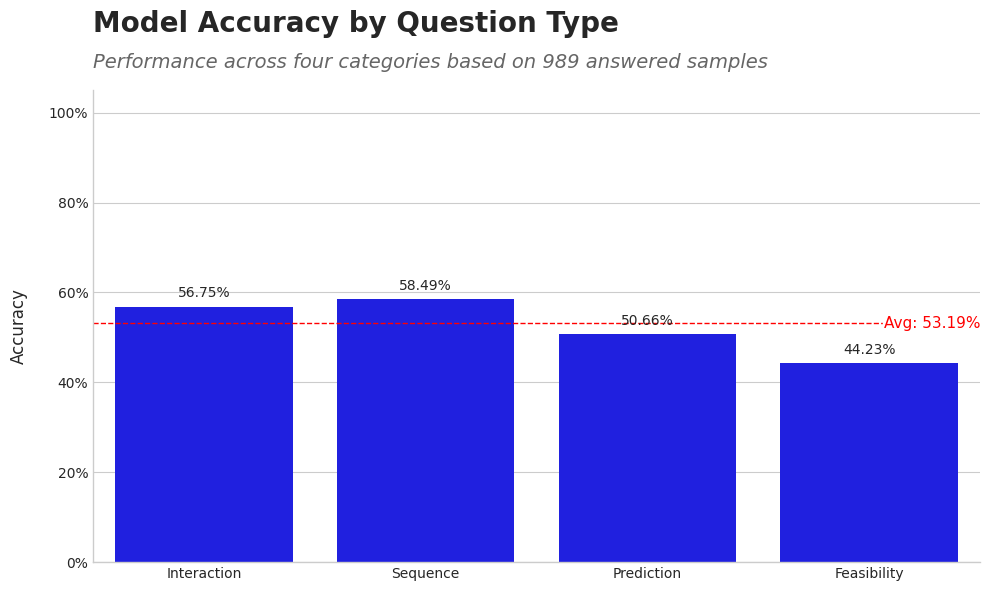

In [227]:
rp.plot_acc(gemma_eval_df, lambda x: rp.accuracy(x, on_what='text'))


In [228]:
rp.print_ans_perc(gemma_eval_df, gt_df)


Question type       Total      Answered 

Interaction          298        96.98%  
Sequence             291        91.07%  
Prediction           239        94.98%  
Feasibility          220        94.55%  
Overall             1048        94.37%  


/home/lusha/star_code/src/response_processing.py:485: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),


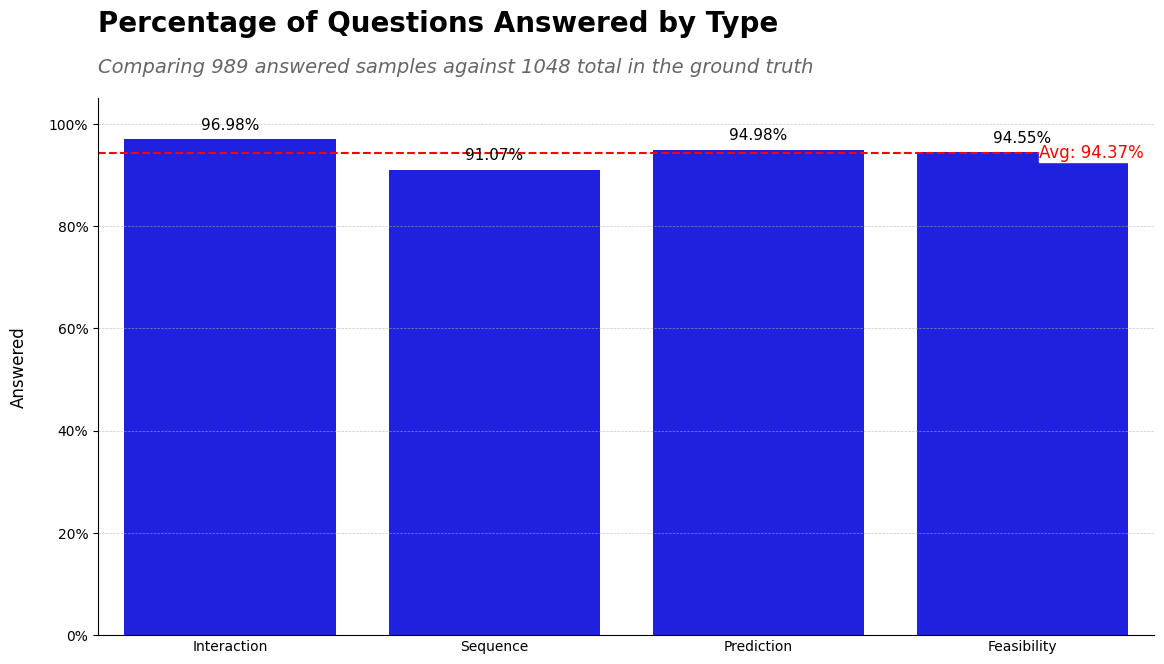

In [229]:
rp.plot_ans_perc(gemma_eval_df, gt_df)


In [230]:
gemini_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemini_eval_df = gt_df.join(
    gemini_pred_gg_df[gemini_pred_gg_df['contains_answer']], 
    how='inner' # we account also for samples without answers
)
rp.print_acc(gemini_eval_df, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          36         72.22%  
Sequence             37         83.78%  
Prediction           39         64.10%  
Feasibility          38         42.11%  

Average              150        65.33%  


/home/lusha/star_code/src/response_processing.py:416: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(3.5, average_accuracy + 2, f'Average: {average_accuracy:.2f}%',


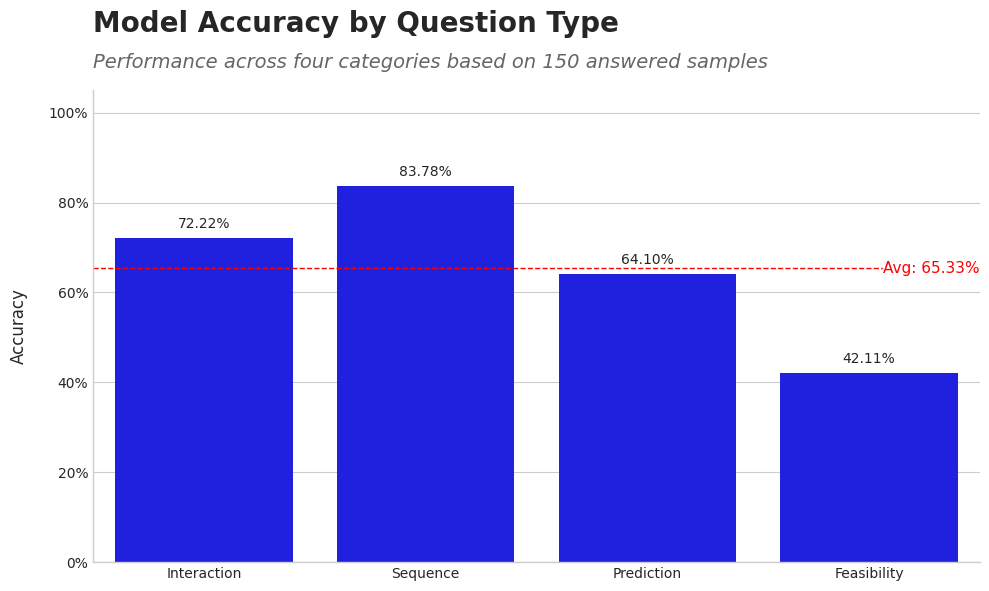

In [231]:
rp.plot_acc(gemini_eval_df, lambda x: rp.accuracy(x, on_what='text'))


In [232]:
rp.print_ans_perc(gemini_eval_df, gt_df)


Question type       Total      Answered 

Interaction          298        12.08%  
Sequence             291        12.71%  
Prediction           239        16.32%  
Feasibility          220        17.27%  
Overall             1048        14.31%  


/home/lusha/star_code/src/response_processing.py:485: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),


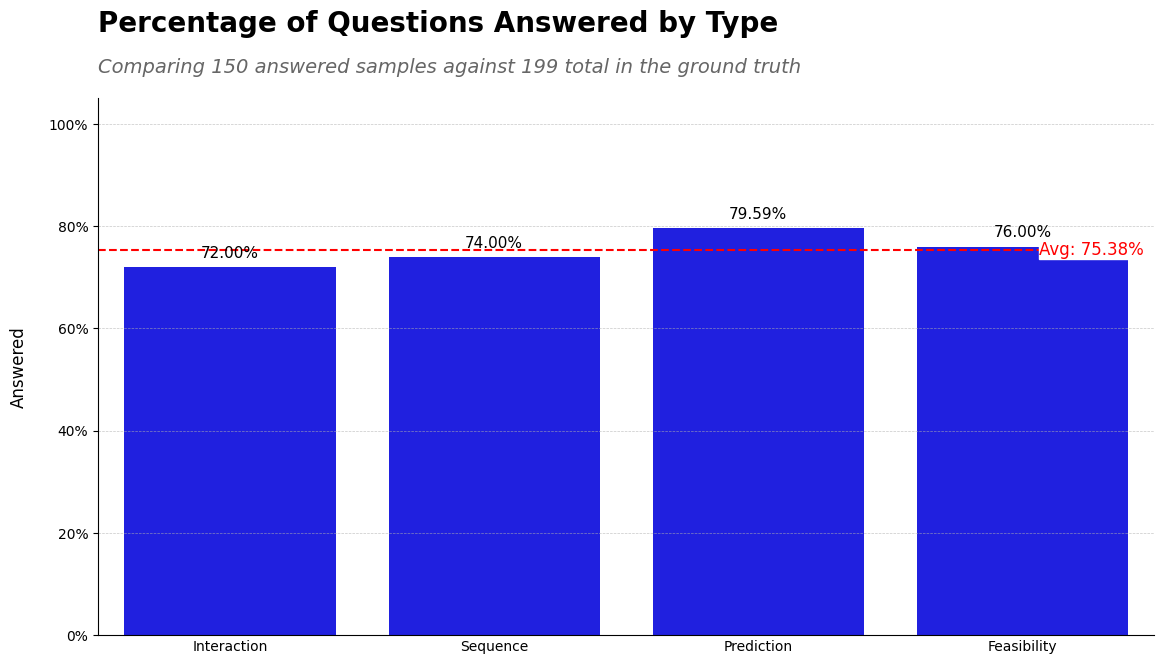

In [233]:
rp.plot_ans_perc(gemini_eval_df, gemini_pred_gg_df)


In [234]:
eval_df_all = gt_df.join(
    gemma_pred_gg_df[gemma_pred_gg_df['contains_answer']].rename(columns={'pred_text': 'pred_text1'})[['pred_text1']],
    how='inner'
).join(
    gemini_pred_gg_df[gemini_pred_gg_df['contains_answer']].rename(columns={'pred_text': 'pred_text2'})[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all[['question', 'text', 'pred_text1', 'pred_text2']]


,question,text,pred_text1,pred_text2
Interaction_T1_2354,Which object was put down by the person?,the towel.,the towel.,the towel.
Prediction_T4_1805,Which object would the person close next after...,the closet/cabinet.,the closet/cabinet.,the closet/cabinet.
Feasibility_T5_438,Which object is the person able to put down af...,the clothes.,the clothes.,the clothes.
Interaction_T2_3685,What did the person do with the sofa/couch?,sat on.,sat on.,sat on.
Interaction_T1_4527,Which object was taken by the person?,the blanket.,the blanket.,the blanket.
...,...,...,...,...
Interaction_T1_8913,Which object was taken by the person?,the paper/notebook.,the paper/notebook.,the paper/notebook.
Interaction_T1_8967,Which object was taken by the person?,the dish.,the towel.,the dish.
Interaction_T2_1847,What did the person do with the paper/notebook?,took.,put down.,put down.
Interaction_T2_3423,What did the person do with the bed?,lied on.,sat on.,sat on.


In [235]:
print(f"Questions answered by both models: \n - {eval_df_all.shape[0]}")


Questions answered by both models: 
 - 145


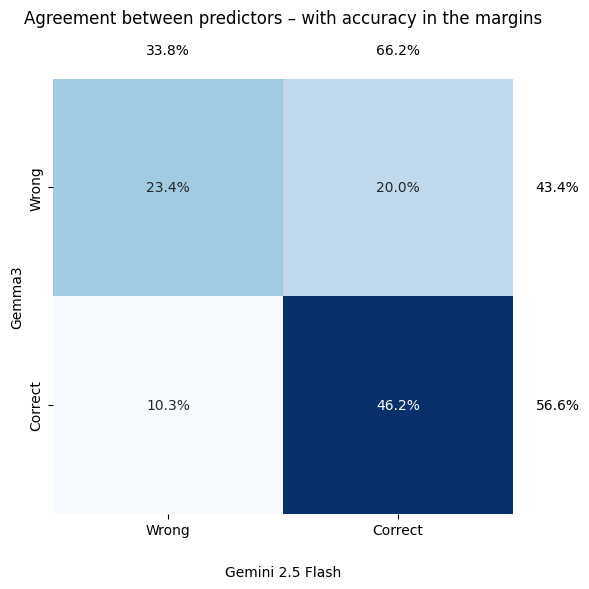

(145, 10)


In [236]:
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))  
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gemini 2.5 Flash', labelpad=20)
ax.set_ylabel('Gemma3')
ax.set_title('Agreement between predictors – with accuracy in the margins', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()
print(eval_df_all.shape)


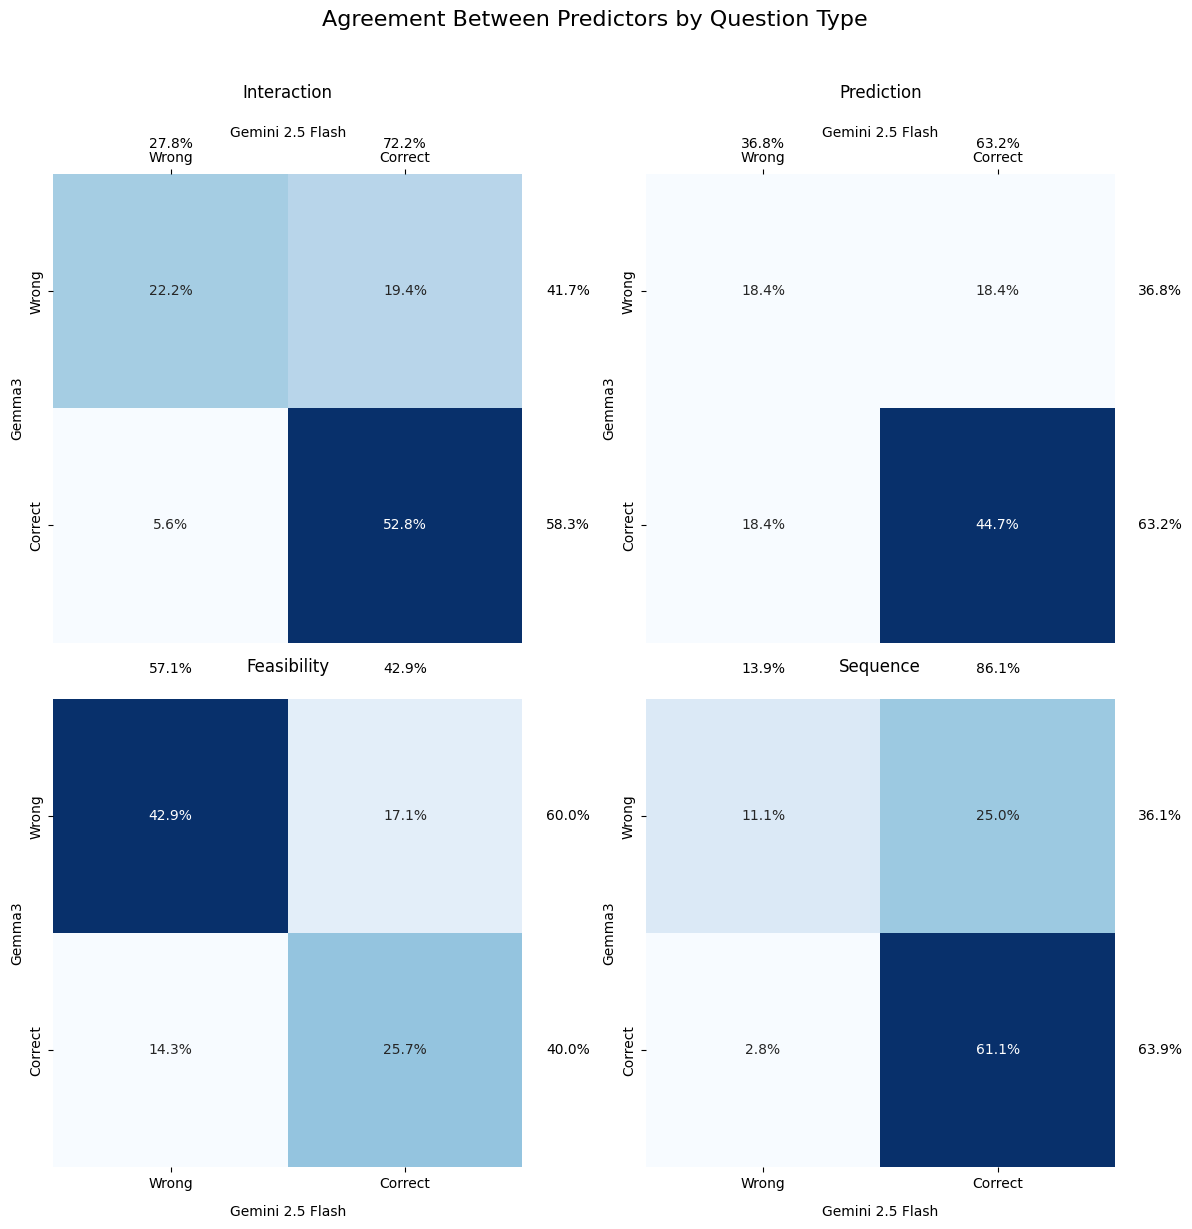

In [237]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Get unique question types
question_types = viz_df['question_type'].unique()

# Set up the plot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Agreement Between Predictors by Question Type', y=1.02, fontsize=16)

# Flatten axes for easy iteration
axes = axes.flatten()

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Calculate correctness
    pred_vqa_correct = (subset['text'] == subset['pred_text1']).astype(int).values
    pred_gg_correct = (subset['text'] == subset['pred_text2']).astype(int).values
    
    # Confusion matrix (normalized over all)
    cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')
    
    # Compute marginal sums
    row_totals = cm.sum(axis=1)
    col_totals = cm.sum(axis=0)
    total = cm.sum()
    row_pct = row_totals / total
    col_pct = col_totals / total
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                cbar=False, ax=axes[i])
    
    # Annotate row marginals
    for j, p in enumerate(row_pct):
        axes[i].text(len(labels) + 0.1, j + 0.5, f'{p:.1%}', 
                    va='center', ha='left', fontsize=10)
    
    # Annotate column marginals
    for k, p in enumerate(col_pct):
        axes[i].text(k + 0.5, -0.1, f'{p:.1%}', 
                    ha='center', va='bottom', fontsize=10)
    
    # Customize subplot
    axes[i].set_title(qtype, pad=20)
    axes[i].set_xlabel('Gemini 2.5 Flash', labelpad=10)
    axes[i].set_ylabel('Gemma3')
    axes[i].set_xticklabels(labels, rotation=0)
    
    # Move x-axis to top for all but bottom row
    if i < 2:  # Top row
        axes[i].xaxis.set_ticks_position('top')
        axes[i].xaxis.set_label_position('top')

plt.tight_layout()
plt.show()


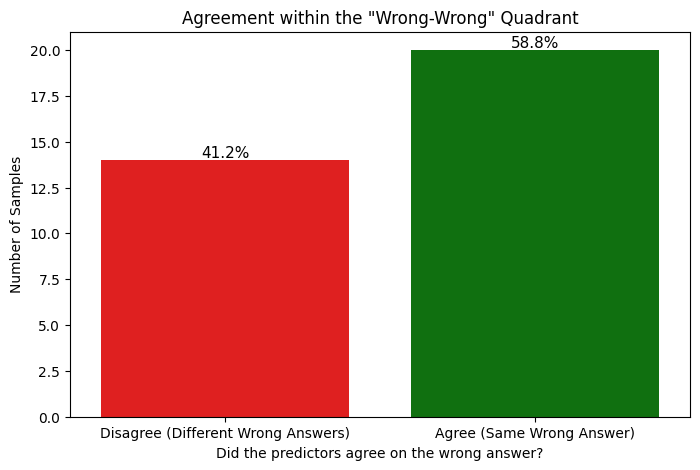

In [238]:
wrong_wrong_df = eval_df_all[
    (eval_df_all['text'] != eval_df_all['pred_text1']) &
    (eval_df_all['text'] != eval_df_all['pred_text2'])
].copy()

wrong_wrong_df['agreement_on_wrong'] = (
    wrong_wrong_df['pred_text1'] == wrong_wrong_df['pred_text2']
)

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=wrong_wrong_df,
    x='agreement_on_wrong',
    hue='agreement_on_wrong',
    palette=['Red', 'Green'],
    legend=False
)

plt.title('Agreement within the "Wrong-Wrong" Quadrant')
plt.ylabel('Number of Samples')
plt.xlabel('Did the predictors agree on the wrong answer?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree (Different Wrong Answers)', 'Agree (Same Wrong Answer)'])

# Add percentage annotations
total = len(wrong_wrong_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_2628597/1012052540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


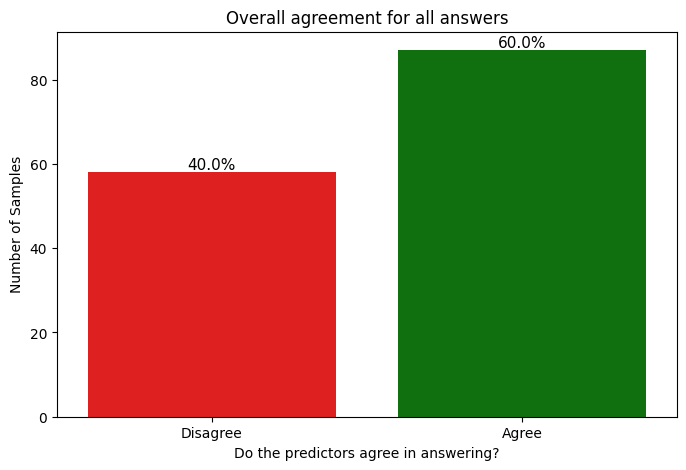

In [239]:
agreement_df = pd.DataFrame((eval_df_all['pred_text1'] == eval_df_all['pred_text2']), columns=['agreement'])

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=agreement_df,
    x='agreement',
    palette=['Red', 'Green']
)

plt.title('Overall agreement for all answers')
plt.ylabel('Number of Samples')
plt.xlabel('Do the predictors agree in answering?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree', 'Agree'])

# Add percentage annotations
total = len(agreement_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_2628597/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


/tmp/ipykernel_2628597/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_2628597/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_2628597/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


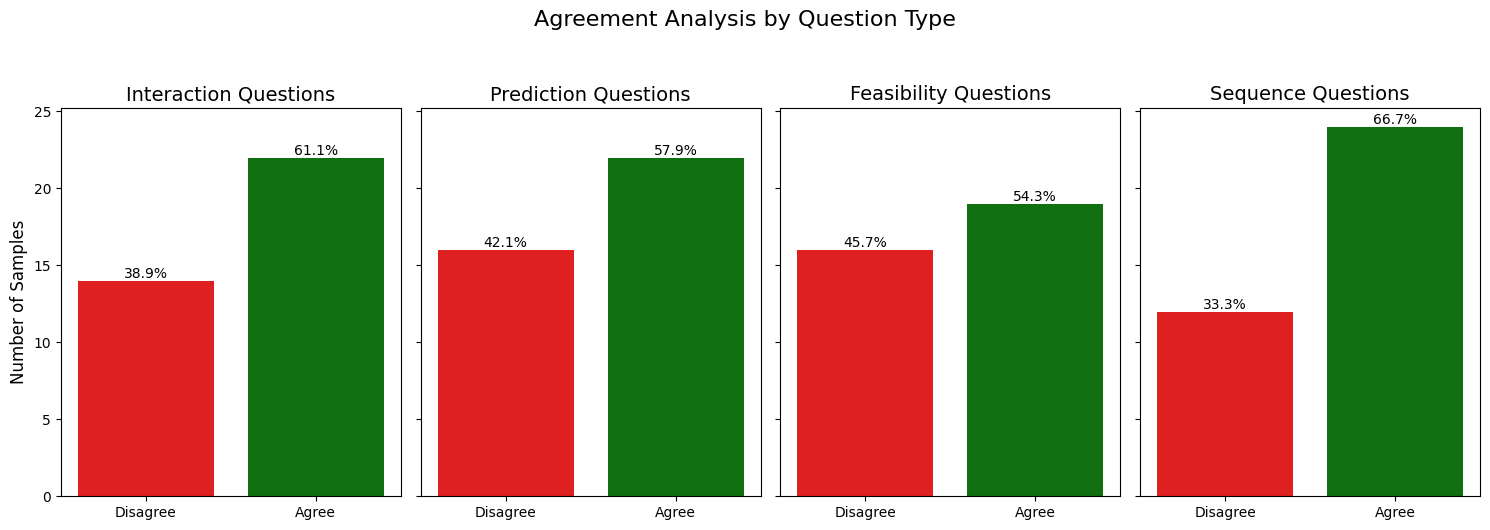

In [240]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Create agreement column in the copy
viz_df['agreement'] = viz_df['pred_text1'] == viz_df['pred_text2']

# Get unique question types
question_types = viz_df['question_type'].unique()
n_types = len(question_types)

# Create subplots
fig, axes = plt.subplots(1, n_types, figsize=(15, 5), sharey=True)
fig.suptitle('Agreement Analysis by Question Type', fontsize=16, y=1.05)

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Create countplot
    ax = sns.countplot(
        data=subset,
        x='agreement',
        palette=['Red', 'Green'],
        ax=axes[i]
    )
    
    # Set title and labels
    ax.set_title(f'{qtype} Questions', fontsize=14)
    ax.set_xlabel('')
    if i == 0:
        ax.set_ylabel('Number of Samples', fontsize=12)
    
    # Set x-ticks
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Disagree', 'Agree'])
    
    # Add percentage annotations
    total = len(subset)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## Inspection - 1
Check why Gemini doesn't answer some on the questions

In [241]:
gemma_pred_gg_df = rp.ans_extract(GEMMA_RESPONSES_FPATH, "gemma3", format="ollama")
gemini_pred_gg_df = rp.ans_extract(GEMINI_RESPONSES_FPATH, "gemma3", format="gemini")


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
Error executing eval on: {  "answer": "Based on the provided Spatio-Temporal Scene Graph, the person does not close any object before holding a 'small_dark_object' (Frame 4) or a 'mobile_phone' (Frame 5). The 'upper_cabinet' door, which the person interacts with, is explicitly stated to be 'open' from Frame 3 until the end of the sequence (Frame 8). Therefore, none of the alternatives are supported by the given STSG as an action that occurred. Since I must choose one of the alternatives, and acknowledging the lack of evidence for any closing action, it is impossible to definitively select a correct answer from the given options based on the provided STSG. If forced to choose the "closest" related object, it would be the cabinet/door, but the ac

Total answers: 1032
Answers following JSON template: 1032
Percentage following JSON template: 100.00%
Answer with a valid alternative: 989
95.83% of the total

Invalid answers: 43
Total answers: 199
Answers following JSON template: 199
Percentage following JSON template: 100.00%
Answer with a valid alternative: 150
75.38% of the total

Invalid answers: 49


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [242]:
gemini_unanswered = gemini_pred_gg_df[~gemini_pred_gg_df['contains_answer']]
gemini_unanswered_index = gemini_unanswered.index


### Sample

In [473]:
SHOW_VIDEO = True
idx = gemini_unanswered_index[9]
idx


'Interaction_T1_4703'

In [474]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [gemini_pred_gg_df.rename(columns={'answer': 'pred_text'})])



┌─ Sample: Interaction_T1_4703 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The broom.
│    1. The phone/camera.
│    2. The towel.
│    3. The clothes.
│
│ Ground Truth:
│    The phone/camera.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│         [WRONG]
│    Reasoning:
│        
│        1. **Question Interpretation**: The question asks to identify an object that the person was holding or carrying, based on the provided Spatio-Temporal Scene Graph.
│        
│        2. **STSG Analysis**:
│            *   **Frame 0**: Introduces the scene, a hallway with a white door, and a person visible on the right wearing a reddish-brown shirt. No objects are mentioned in possession of the person.
│            *   **Frame 1**: "person ---- holds ---- dark_object", "dark_object ---- held_by ---- person's_right_hand", "dark_object ---- by_the_side_of ---- person". This frame explicitly st

In [475]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][0]['content'])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
white_door ---- at_the_end_of ---- hallway
windowpanes ---- on ---- white_door
curtain ---- covers ---- windowpanes
curtain ---- on_right_side_of ---- white_door
doorway ---- to_the_left_of ---- white_door
room ---- beyond ---- doorway
doorway ---- to_the_right_of ---- white_door
utility_area ---- beyond ---- doorway
person ---- visible_on_right_of ---- frame
person ---- wears ---- reddish-brown_shirt
</scene_graph>

Frame 1:
<scene_graph>
person ---- moves_into ---- frame
person ---- holds ---- dark_object
dark_object ---- held_by ---- person's_right_hand
dark_object ---- by_the_side_of ---- person
</scene_graph>

Frame 2:
<scene_graph>
person ---- takes_step_forward ---- towards_white_door
person ---- wears ---- dark_trousers
person ---- wears ---- striped_reddish-brown_shirt
person's_body ---- faces ---- whit

In [476]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][1]['content'])



1. **Question Interpretation**: The question asks to identify an object that the person was holding or carrying, based on the provided Spatio-Temporal Scene Graph.

2. **STSG Analysis**:
    *   **Frame 0**: Introduces the scene, a hallway with a white door, and a person visible on the right wearing a reddish-brown shirt. No objects are mentioned in possession of the person.
    *   **Frame 1**: "person ---- holds ---- dark_object", "dark_object ---- held_by ---- person's_right_hand", "dark_object ---- by_the_side_of ---- person". This frame explicitly states the person holds a "dark_object".
    *   **Frame 2, 3, 4, 5, 6**: These frames describe the person's movement towards and interaction with the white door (opening it). There is no further mention of the "dark_object" or any other specific object being held by the person. The focus shifts to the action of opening the door.

3. **Alternative Evaluation**:
    *   **A. The broom**: The STSG mentions a "dark_object" but does not spe

In [477]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][3]['content'])



```json
{
 "answer": "The provided Spatio-Temporal Scene Graph states that the person holds a 'dark_object' in Frame 1. However, the STSG does not give any more specific details about what this 'dark_object' is. Therefore, based on the information provided in the STSG, it is not possible to determine which specific object was taken by the person from the given alternatives (A. The broom, B. The phone/camera, C. The towel, D. The clothes). The STSG does not support any of the specific object types listed in the alternatives."
}
```


#### Gemma

In [ ]:
importlib.reload(qa_viz)


<module 'src.viz_utils.qa_viz' from '/home/lusha/star_code/src/viz_utils/qa_viz.py'>

In [479]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [gemma_pred_gg_df.rename(columns={'answer': 'pred_text'})])



┌─ Sample: Interaction_T1_4703 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The broom.
│    1. The phone/camera.
│    2. The towel.
│    3. The clothes.
│
│ Ground Truth:
│    The phone/camera.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│        The towel. [WRONG]
│    Reasoning:
│        Okay, let's analyze the scene graph and answer the question.
│        
│        1. **Question Interpretation:** The question asks: “Which object was taken by the person?” This implies we need to identify an object the person is holding or interacting with in a way that suggests they are carrying it.
│        
│        2. **STSG Analysis:**
│           * **Frames 1-5:** The scene graph describes the person’s actions and interactions. In Frame 1, the person has a dark object held in their right hand. In Frame 2, the right hand is swinging forward as the person walks, and the dark object is he

In [480]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
white_door ---- at_center_of ---- frame
white_door ---- has_window ---- true
window ---- on_top_of ---- white_door
white_door ---- adorned_with ---- curtain
curtain ---- on_right_side_of ---- window
curtain ---- is_checkered ---- true
curtain ---- has_color ---- green_and_white
doorway ---- on_left_side_of ---- white_door
doorway ---- has ---- gold_doorknob
person ---- partially_visible_on ---- right_side_of_frame
person ---- partially_obscured_by ---- doorframe
</scene_graph>

Frame 1:
<scene_graph>
person ---- moved_further_into ---- frame
person ---- on_right_side_of ---- frame
person ---- has ---- right_hand
right_hand ---- holding ---- dark_object
dark_object ---- held_close_to ---- person's_side
</scene_graph>

Frame 2:
<scene_graph>
person ---- walking_towards ---- white_door
person ---- wearing ---- strip

In [481]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][1]['content'])


Okay, let's analyze the scene graph and answer the question.

1. **Question Interpretation:** The question asks: “Which object was taken by the person?” This implies we need to identify an object the person is holding or interacting with in a way that suggests they are carrying it.

2. **STSG Analysis:**
   * **Frames 1-5:** The scene graph describes the person’s actions and interactions. In Frame 1, the person has a dark object held in their right hand. In Frame 2, the right hand is swinging forward as the person walks, and the dark object is held close to the person’s side. In Frame 3, the right hand is raised slightly and indicates an intention to interact with the door. In Frame 4, the right hand reaches towards the doorknob. Finally, in Frame 5, the right hand is *on* the doorknob. This strongly suggests the person is holding or interacting with the dark object.

3. **Alternative Evaluation:**
   * **A. The broom:** The scene graph doesn’t mention a broom.
   * **B. The phone/came

In [482]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][3]['content'])


```json
{"answer": "C. The towel."}
```


In [ ]:
gemma_pred_gg_df.loc[idx]


chat_history       [{'role': 'user', 'content': 'Please carefully...
contains_answer                                                 True
answer                                                    The towel.
Name: Interaction_T1_4703, dtype: object

In [484]:
gemma_eval_df.loc[idx]


question                        Which object was taken by the person?
video_id                                                        TETZ7
start                                                            12.5
end                                                              19.5
text                                                The phone/camera.
question_program    [{'function': 'Situations', 'value_input': []}...
choices             [{'choice_id': 0, 'choice': 'The broom.', 'cho...
situations          {'000434': {'rel_pairs': [['o000', 'o014'], ['...
chat_history        [{'role': 'user', 'content': 'Please carefully...
contains_answer                                                  True
pred_text                                                  The towel.
Name: Interaction_T1_4703, dtype: object

#### Inspect frames

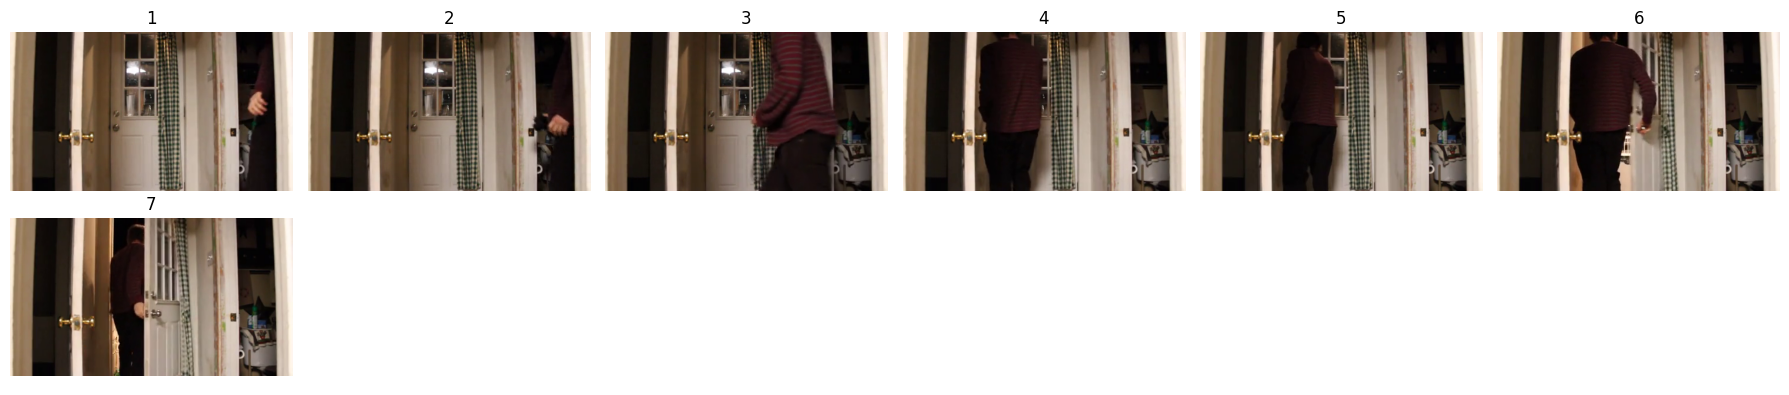

In [485]:
import math

frames_per_row = 6

if SHOW_VIDEO:
    video_path = RAW_VIDEO_DIR / f"{gt_df.loc[idx]['video_id']}.mp4"
    start = gt_df.loc[idx]['start']
    end = gt_df.loc[idx]['end']
    # values used in the experiments
    fps = 1
    max_frames = 64

    frame_dir, frame_paths = video_tools.extract_frames(
        video_path,
        fps=fps,
        max_frames=max_frames,
        start_time=start,
        end_time=end,
    )
    
    frames_per_row = min(frames_per_row, len(frame_paths))
    rows = math.ceil(len(frame_paths) / frames_per_row)
    
    images = frame_paths
    fig, axes = plt.subplots(rows, frames_per_row, figsize=(18, 4))
    axes = axes.flatten()
    
    for i, img_path in enumerate(images):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{i+1}")
        axes[i].axis('off')
    
    # Turn off the axes for any remaining subplots
    for i in range(len(images), len(axes)):
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()


#### Inspect the video

In [486]:
if SHOW_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)


	Video Seg:  12.5s - 19.5s


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

## Inspection - 2

In [183]:
filtered_prev_analyzed = [x for x in prev_analyzed if x in gemini_eval_df.index]
len(filtered_prev_analyzed)


10

In [184]:
rp.print_acc(gemini_eval_df.loc[filtered_prev_analyzed], lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          10         70.00%  
Sequence              0          nan%   
Prediction            0          nan%   
Feasibility           0          nan%   

Average              10         70.00%  


/home/lusha/star_code/src/response_processing.py:295: RuntimeWarning: invalid value encountered in scalar divide
  return hits_text / eval_df.shape[0]


In [185]:
correct_idx = (gemini_eval_df.loc[filtered_prev_analyzed, 'text'] == gemini_eval_df.loc[filtered_prev_analyzed, 'pred_text'])
correct_idx =  correct_idx[correct_idx].index
correct_idx


Index(['Interaction_T1_8913', 'Interaction_T1_4115', 'Interaction_T1_2516',
       'Interaction_T1_8967', 'Interaction_T1_111', 'Interaction_T1_8274',
       'Interaction_T1_4221'],
      dtype='object')

In [186]:
idx = correct_idx[0]


In [187]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [gemini_pred_gg_df])



┌─ Sample: Interaction_T1_8913 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The paper/notebook.
│    1. The laptop.
│    2. The bag.
│    3. The cup/glass/bottle.
│
│ Ground Truth:
│    The paper/notebook.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:  The paper/notebook. [CORRECT]
│    Reasoning:
│        
│        1. **Question Interpretation:** The question asks to identify which object the person (man) took based on the provided Spatio-Temporal Scene Graph.
│        
│        2. **STSG Analysis:**
│            *   **Frame 0:** The man is moving towards the chair. A smartphone is on the bed and a laptop is on the desk. No object is being taken yet.
│            *   **Frame 1:** The man is sitting on the chair. His left hand is holding a "thin_object" which is not explicitly identified as being taken *from* somewhere. The laptop is on the desk, and the smartphone is on the be

In [188]:
if SHOW_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)


In [189]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][0]['content'])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
man ---- in_motion_towards ---- chair
man ---- facing_towards ---- right
man ---- leaning_forward ---- null
man ---- hands_down ---- null
bed ---- to_the_left_of ---- man
smartphone ---- on_top_of ---- bed
desk ---- to_the_right_of ---- man
laptop ---- on_top_of ---- desk
laptop ---- displaying ---- screen
screen ---- displaying ---- text
mouse ---- near ---- laptop
door ---- behind ---- desk
</scene_graph>

Frame 1:
<scene_graph>
man ---- sitting_on ---- chair
man ---- facing_towards ---- null
man ---- looking_down_and_to_the_right ---- null
man ---- hands_in ---- lap
left_hand ---- holding ---- thin_object
laptop ---- on_top_of ---- desk
laptop ---- open_and_illuminated ---- null
bed ---- to_the_left_of ---- man
smartphone ---- on_top_of ---- bed
door ---- behind ---- desk
</scene_graph>

Frame 2:
<scene_graph